who else spent big on political-ish FB ads around the may 2022 election, and how do their patterns compare. input is v3 from notebook 04, advocacy rows only.

setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum as spark_sum, count as spark_count, countDistinct,
    when, lit, date_trunc, desc, broadcast,
)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

spark = SparkSession.builder \
    .appName('FB_API_election_spenders') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/20 11:37:01 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'

ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START  = pd.Timestamp('2021-11-21')
WINDOW_END    = pd.Timestamp('2022-11-21')

# Consistent palette across every chart in this notebook so the same advertiser
# type reads the same colour everywhere.
GROUP_COLORS = {
    'candidate':           '#1f77b4',   # blue
    'party_org':           '#ff7f0e',   # orange
    'climate':             '#2ca02c',   # green
    'humanitarian_rights': '#d62728',   # red
    'political_advocacy':  '#9467bd',   # purple
    'cost_of_living':      '#8c564b',   # brown
    'mixed':               '#bcbd22',   # olive
}

load v3, drop candidates and parties, tag group and pre/post period, cache.

In [3]:
v3 = spark.read.parquet(V3_PATH)

# Drop candidate and party_org - focus on the advocacy ecosystem only.
v3 = v3.filter(col('match_type').isNull())

# Drop the 'mixed' category. The per-category weekly-spend panels in
# notebook 04 show 'mixed' carries no election signal (flat and noisy,
# with no pre-election ramp), unlike the other four categories. It is
# therefore excluded from the temporal banding analysis.
v3 = v3.filter(col('category') != 'mixed')

# Use category as the group label (climate / humanitarian_rights / political_advocacy / cost_of_living).
v3 = v3.withColumn('group', col('category'))

# Tag pre/post election by ad creation date.
v3 = v3.withColumn(
    'period',
    when(col('ad_creation_date') < lit('2022-05-21'), 'pre')
    .otherwise('post')
)

v3 = v3.cache()
print(f'Advocacy ads in v3: {v3.count():,}')
print('\nGroup distribution:')
v3.groupBy('group').agg(
    spark_count('*').alias('ads'),
    spark_sum('spend_mid').alias('total_spend'),
).orderBy(desc('total_spend')).show(truncate=False)

26/05/20 11:37:17 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


26/05/20 11:37:32 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


26/05/20 11:37:47 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


26/05/20 11:38:02 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


26/05/20 11:38:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Advocacy ads in v3: 78,524

Group distribution:


+-------------------+-----+-----------+
|group              |ads  |total_spend|
+-------------------+-----+-----------+
|political_advocacy |34108|7886996.0  |
|climate            |28981|7201909.5  |
|humanitarian_rights|9076 |3236462.0  |
|cost_of_living     |6359 |2267220.5  |
+-------------------+-----+-----------+



top 20 bylines by pre-election spend, with post spend and modal group. banding happens later in cell 11.

In [4]:
# per-byline pre and post spend totals.
byline_spend = (v3
    .filter(col('spend_mid').isNotNull() & col('bylines').isNotNull())
    .groupBy('bylines')
    .pivot('period', ['pre', 'post'])
    .agg(spark_sum('spend_mid'))
).na.fill(0)

# modal group per byline.
group_per_byline = (v3.filter(col('bylines').isNotNull())
    .groupBy('bylines', 'group').count()
    .toPandas())

primary_group = (group_per_byline
    .sort_values(['bylines', 'count'], ascending=[True, False])
    .drop_duplicates('bylines', keep='first')
    [['bylines', 'group']])

spend_pdf = byline_spend.toPandas()
spend_pdf.columns = ['bylines', 'pre_spend', 'post_spend']
spend_pdf = spend_pdf.merge(primary_group, on='bylines', how='left')
spend_pdf['total_spend'] = spend_pdf['pre_spend'] + spend_pdf['post_spend']

top20 = spend_pdf.sort_values('pre_spend', ascending=False).head(20).reset_index(drop=True)
top20[['bylines', 'group', 'pre_spend', 'post_spend', 'total_spend']]

,bylines,group,pre_spend,post_spend,total_spend
0,Greenpeace Australia Pacific,climate,775515.5,703431.5,1478947.0
1,Amnesty International Australia,humanitarian_rights,591343.5,137758.0,729101.5
2,Solutions for Australia,climate,588191.0,67405.0,655596.0
3,Climate 200,political_advocacy,479677.0,101032.0,580709.0
4,Australian Conservation Foundation,climate,381886.0,255775.0,637661.0
5,Thrive By Five,humanitarian_rights,374312.0,229296.5,603608.5
6,The Pharmacy Guild of Australia,cost_of_living,335291.5,0.0,335291.5
7,Smart Voting,political_advocacy,297473.5,0.0,297473.5
8,Australian Education Union,climate,253022.5,0.0,253022.5
9,Advance Australia,political_advocacy,242332.0,34869.5,277201.5


cumulative spend per byline. election-only ones elbow at election day, ongoing ones climb steady.

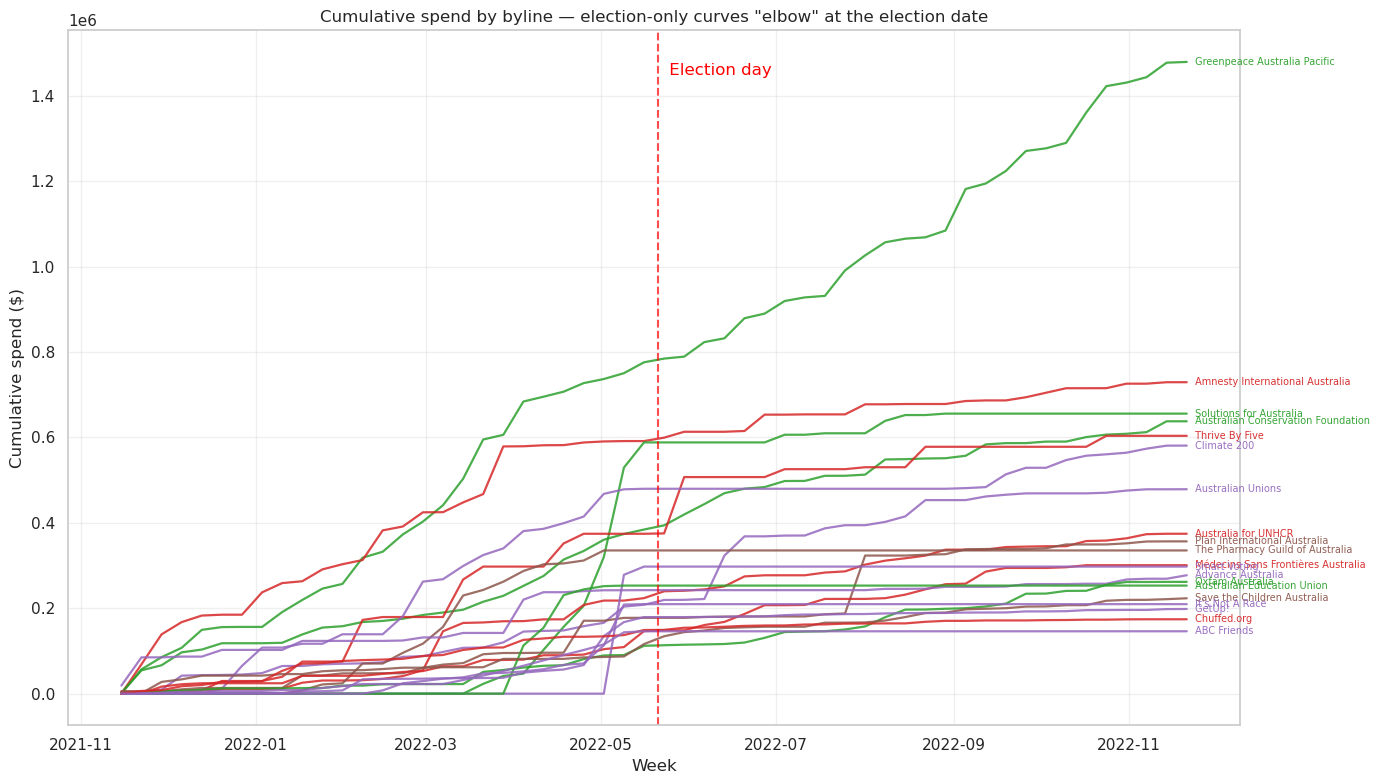

In [5]:
top20_bylines = top20['bylines'].tolist()

# Weekly aggregation per byline — cached on driver as pandas, reused by every chart below.
weekly = (v3
    .filter(col('bylines').isin(top20_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'bylines', 'group')
    .agg(spark_sum('spend_mid').alias('spend'))
    .orderBy('week')
    .toPandas())

# Pivot to byline × week (used by stacked/cumulative/heatmap charts below).
pivot = weekly.pivot_table(index='week', columns='bylines', values='spend', aggfunc='sum').fillna(0)
col_order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]
byline_group = dict(zip(top20['bylines'], top20['group']))

# Cumulative spend per byline — the elbow tells the story.
cumulative = pivot.cumsum()

fig, ax = plt.subplots(figsize=(14, 8))
for byline in cumulative.columns:
    grp = byline_group.get(byline, 'unknown')
    color = GROUP_COLORS.get(grp, '#777777')
    ax.plot(cumulative.index, cumulative[byline],
            color=color, alpha=0.85, linewidth=1.6)
    # End-of-line label
    end_val = cumulative[byline].iloc[-1]
    ax.text(cumulative.index[-1] + pd.Timedelta(days=2),
            end_val, ' ' + byline[:35],
            fontsize=7, va='center', color=color, alpha=0.95)

ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.7, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Cumulative spend by byline — election-only curves "elbow" at the election date')
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative spend ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

smooth the weekly series and compute persistence, centroid and EC off it, then assign each byline to a band.

In [6]:
import numpy as np

HALF_WIDTH_WEEKS = 26
CENTROID_WINDOW  = 16
PERSIST_LOW      = 0.30
PERSIST_HIGH     = 0.80
SMOOTH_WINDOW    = 4

# collapse duplicate (bylines, week) rows that arise when a byline appears in
# more than one group, so the multi-index reindex below is unique.
weekly = (weekly
    .groupby(['bylines', 'week'], as_index=False)['spend'].sum())

# rebuild on a complete week index per byline so the rolling window sees
# zero-spend weeks instead of skipping them.
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
bylines_in_weekly = weekly['bylines'].unique()
full_index = pd.MultiIndex.from_product([bylines_in_weekly, all_weeks],
                                         names=['bylines', 'week'])
weekly = (weekly.set_index(['bylines', 'week'])
                .reindex(full_index, fill_value=0.0)
                .reset_index()
                .sort_values(['bylines', 'week']))

# re-attach group from top20.
weekly = weekly.merge(top20[['bylines', 'group']], on='bylines', how='left')

# 4-week centred rolling mean per byline, with a hard boundary at election day —
# pre and post are smoothed separately so a cliff-edged advertiser's final
# pre-election spike doesn't bleed forward into the post-election weeks.
weekly['is_post'] = weekly['week'] >= ELECTION_DATE
weekly['spend_smooth'] = (weekly.groupby(['bylines', 'is_post'])['spend']
    .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()))

# triangle weights for the EC index.
weekly['weeks_from_election'] = (weekly['week'] - ELECTION_DATE).dt.days / 7
weekly['weight'] = np.clip(
    1.0 - np.abs(weekly['weeks_from_election']) / HALF_WIDTH_WEEKS,
    a_min=0.0, a_max=None,
)
weekly['weighted_spend_smooth'] = weekly['weight'] * weekly['spend_smooth']

# recompute persistence, EC, centroid from the smoothed series.
def _summary(x):
    total = x['spend_smooth'].sum()
    if total <= 0:
        return pd.Series({'pre_spend_s': 0.0, 'post_spend_s': 0.0,
                          'ec_index': 0.0, 'centroid_weeks': 0.0})
    pre = x.loc[~x['is_post'], 'spend_smooth'].sum()
    post = x.loc[x['is_post'], 'spend_smooth'].sum()
    return pd.Series({
        'pre_spend_s':    pre,
        'post_spend_s':   post,
        'ec_index':       x['weighted_spend_smooth'].sum() / total,
        'centroid_weeks': (x['weeks_from_election'] * x['spend_smooth']).sum() / total,
    })

smoothed = weekly.groupby('bylines').apply(_summary).reset_index()
smoothed['persistence'] = smoothed['post_spend_s'] / smoothed['pre_spend_s'].replace(0, pd.NA)

for c in ('persistence', 'ec_index', 'centroid_weeks', 'band'):
    if c in top20.columns:
        top20 = top20.drop(columns=[c])
top20 = top20.merge(
    smoothed[['bylines', 'persistence', 'ec_index', 'centroid_weeks']],
    on='bylines', how='left',
)

def _classify(row):
    p = row['persistence'] if pd.notna(row['persistence']) else 0.0
    c = abs(row['centroid_weeks']) if pd.notna(row['centroid_weeks']) else 0.0
    if p < PERSIST_LOW and c > CENTROID_WINDOW:
        return 'off_campaign'
    if p < PERSIST_LOW:
        return 'election_only'
    if p > PERSIST_HIGH:
        return 'ongoing'
    return 'transitional'

top20['band'] = top20.apply(_classify, axis=1)
top20['band'] = pd.Categorical(
    top20['band'],
    categories=['election_only', 'transitional', 'ongoing', 'off_campaign'],
    ordered=True,
)

display_cols = ['bylines', 'group', 'pre_spend', 'post_spend',
                'persistence', 'ec_index', 'centroid_weeks', 'band']
top20.sort_values(['band', 'total_spend'], ascending=[True, False])[display_cols]

,bylines,group,pre_spend,post_spend,persistence,ec_index,centroid_weeks,band
1,Amnesty International Australia,humanitarian_rights,591343.5,137758.0,0.229716,0.412767,-11.205481,election_only
2,Solutions for Australia,climate,588191.0,67405.0,0.125246,0.852048,-1.475849,election_only
3,Climate 200,political_advocacy,479677.0,101032.0,0.208811,0.517789,-5.495480,election_only
6,The Pharmacy Guild of Australia,cost_of_living,335291.5,0.0,0.000000,0.629485,-9.633387,election_only
7,Smart Voting,political_advocacy,297473.5,0.0,0.000000,0.938750,-1.592509,election_only
9,Advance Australia,political_advocacy,242332.0,34869.5,0.118869,0.365140,-12.244064,election_only
8,Australian Education Union,climate,253022.5,0.0,0.000000,0.802521,-5.134448,election_only
11,It's Not A Race,political_advocacy,209553.0,0.0,0.000000,0.831847,-4.371965,election_only
13,GetUp!,political_advocacy,179247.5,18999.5,0.106415,0.768834,-3.256904,election_only
15,Chuffed.org,humanitarian_rights,148874.5,25262.0,0.184374,0.494781,-10.402506,election_only


stacked area of weekly spend across the top 20.

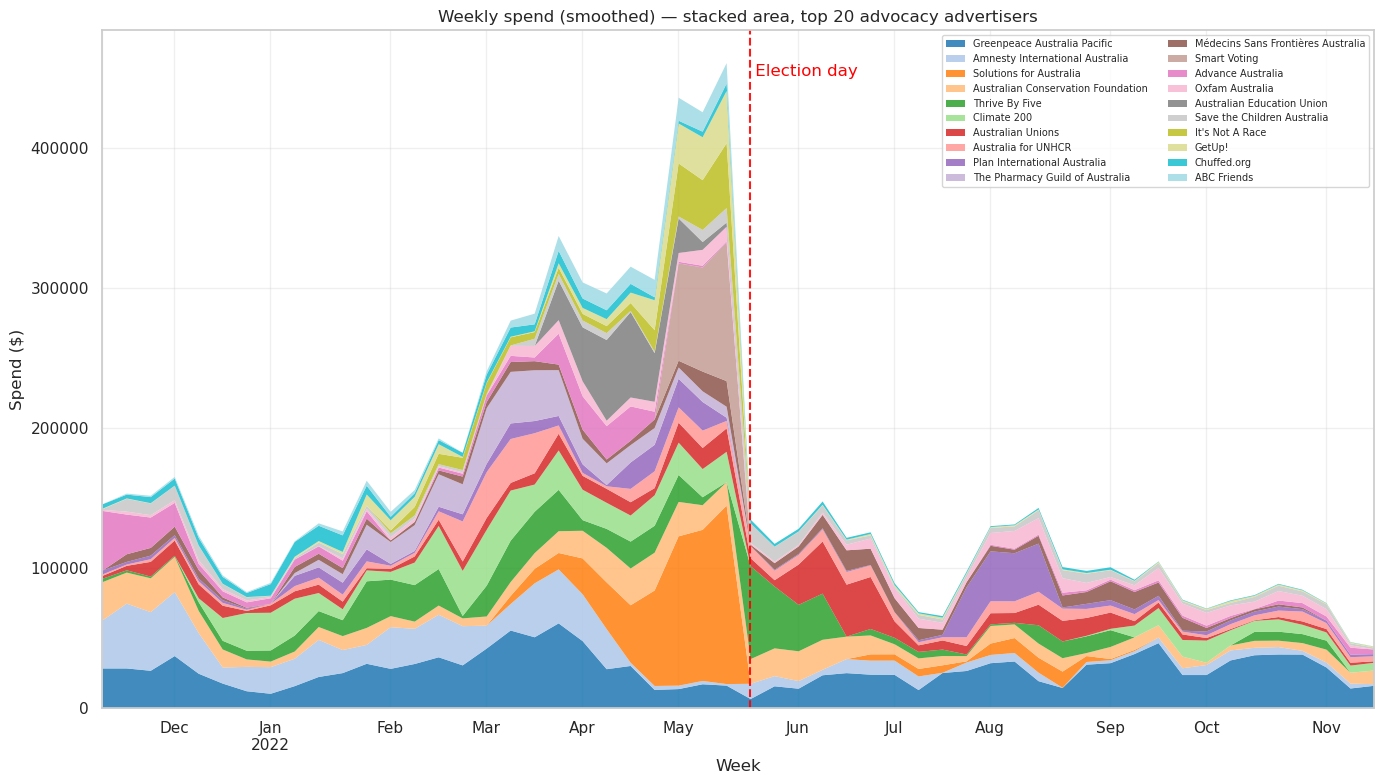

In [7]:
pivot_smooth = (weekly.pivot_table(index='week', columns='bylines',
                                    values='spend_smooth', aggfunc='sum')
                       .fillna(0)
                       [pivot.columns])  # same byline order as the raw pivot

fig, ax = plt.subplots(figsize=(14, 8))
pivot_smooth.plot.area(ax=ax, alpha=0.85, linewidth=0, colormap='tab20')
ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.9, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Weekly spend (smoothed) — stacked area, top 20 advocacy advertisers')
ax.set_ylabel('Spend ($)')
ax.set_xlabel('Week')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

small multiples, one panel per byline, grouped by band. shared x, independent y.

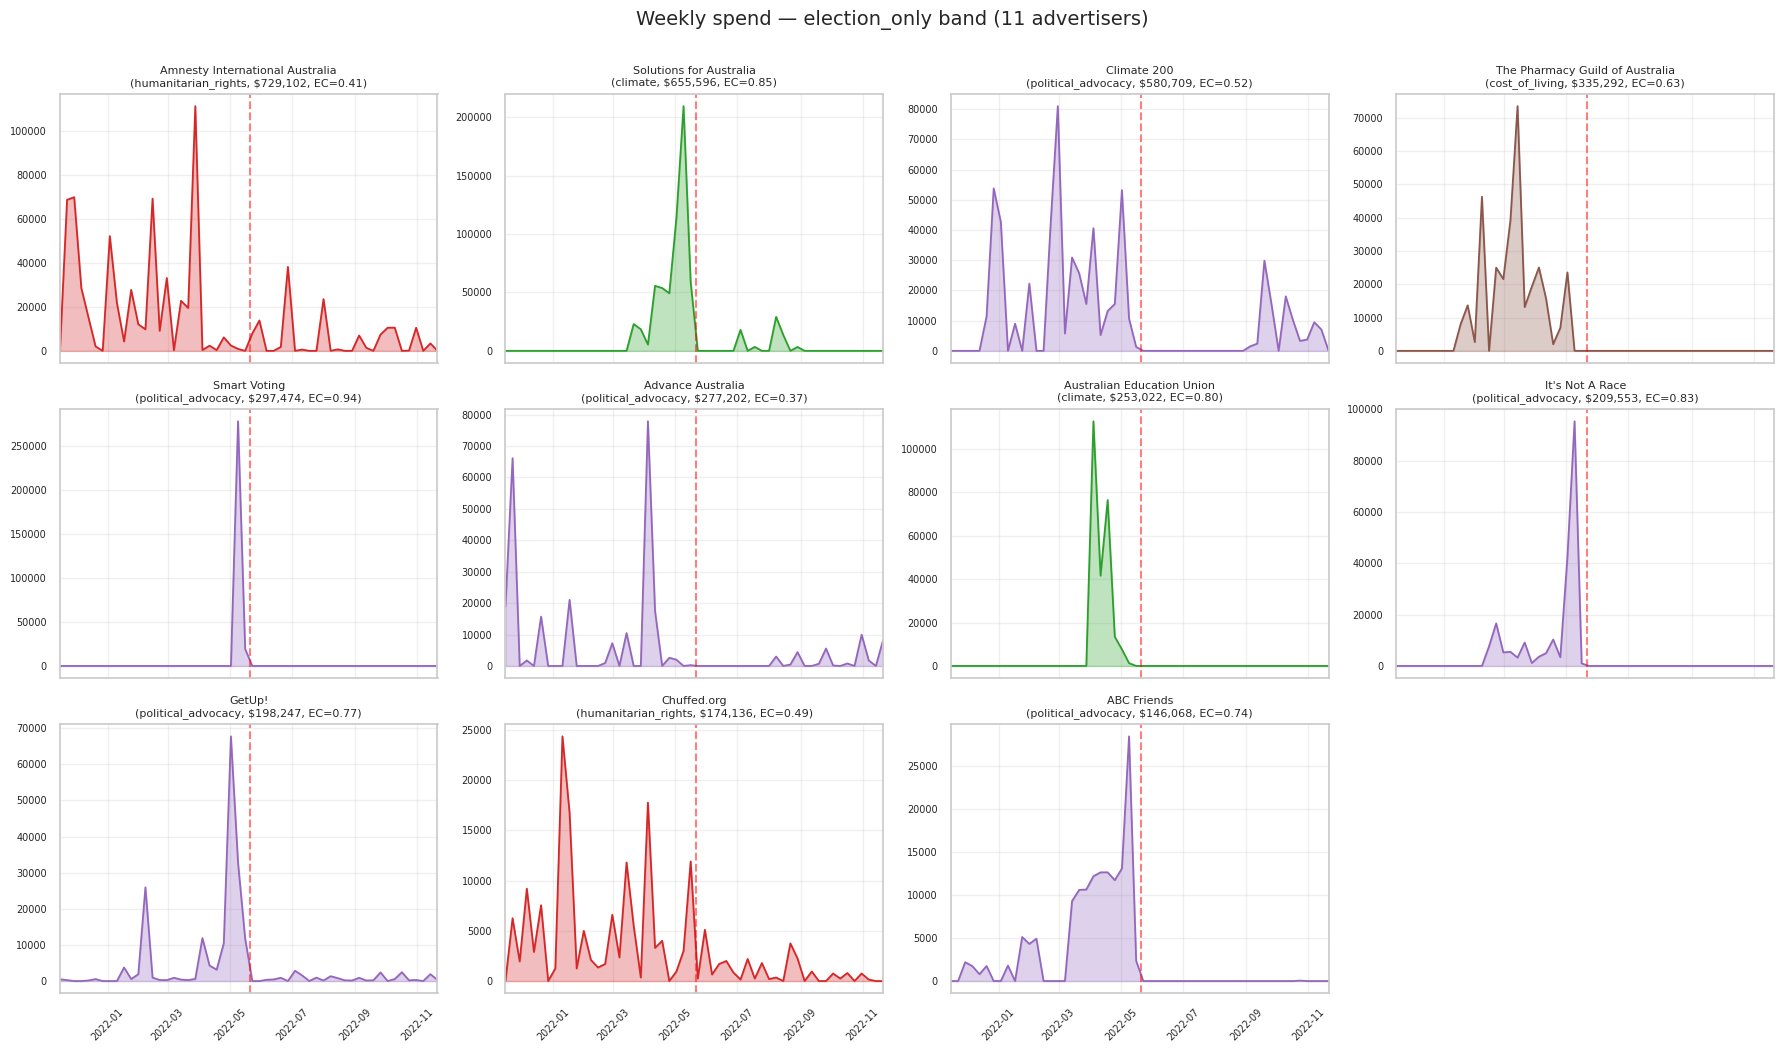

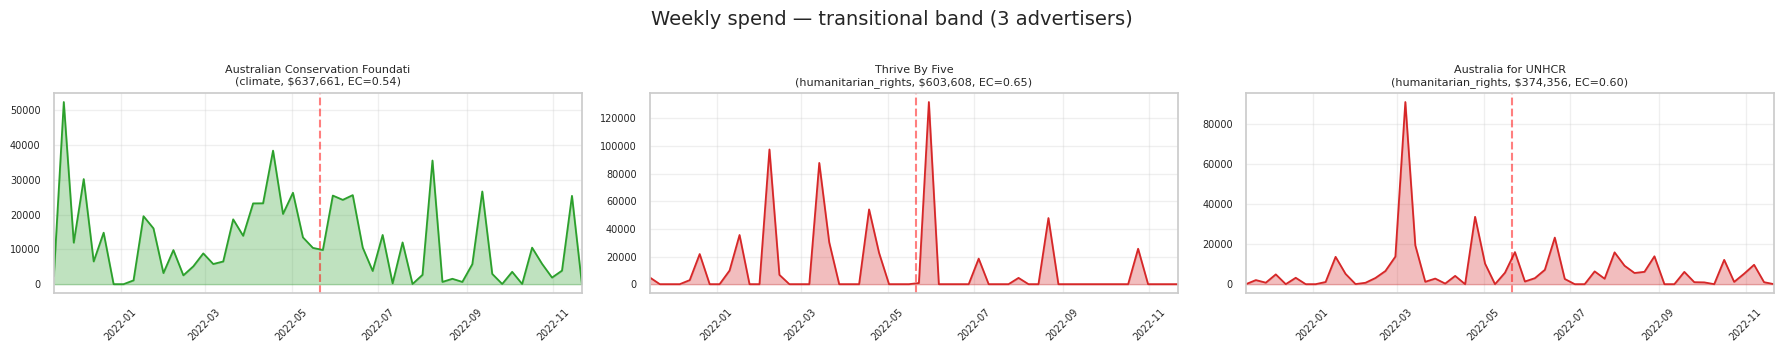

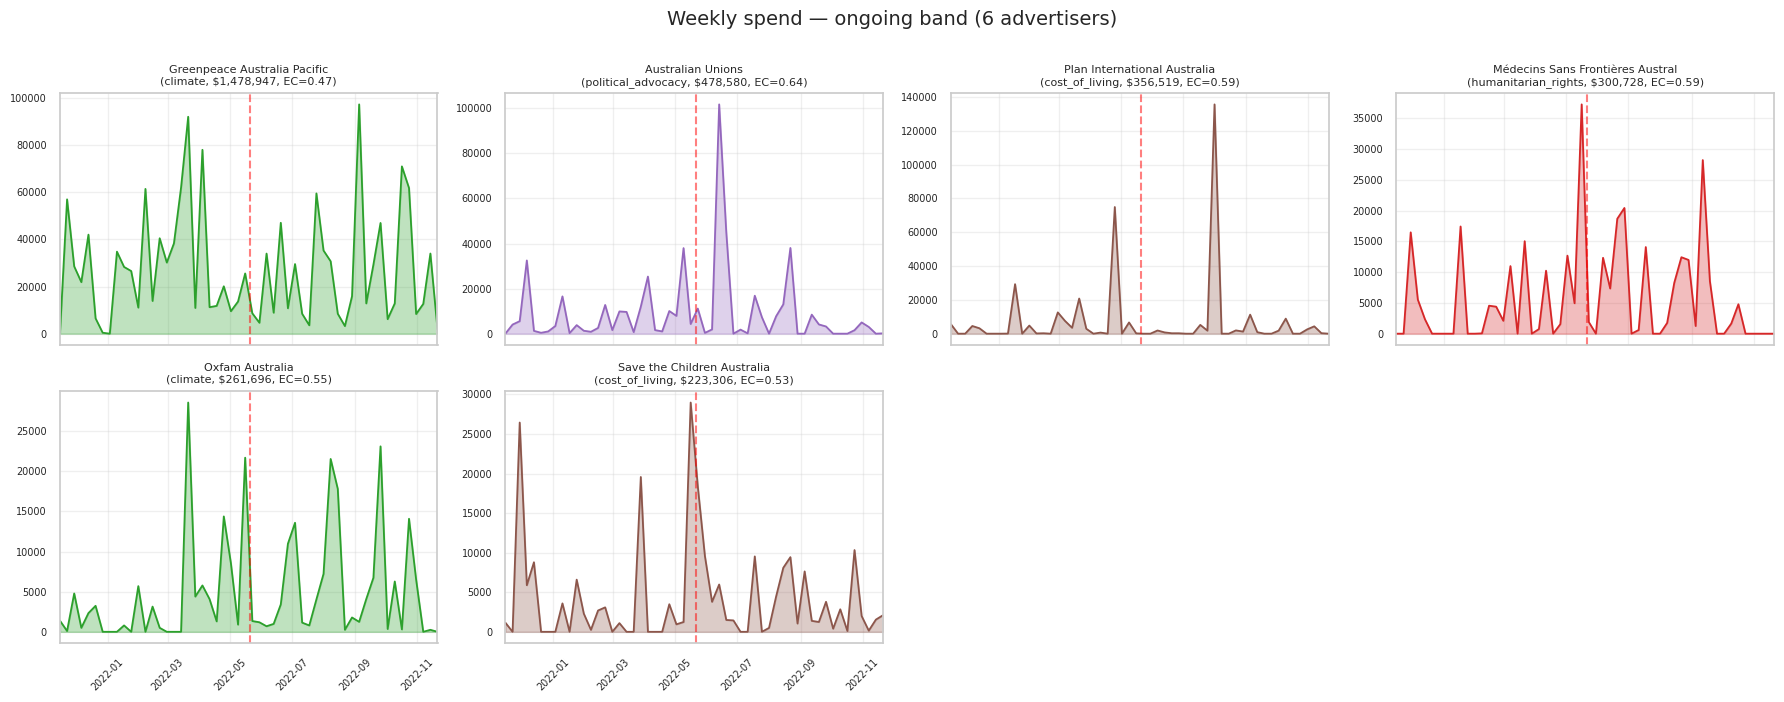

No advertisers in band "off_campaign".



In [8]:
import math

# Full time window for sharex.
x_min = weekly['week'].min()
x_max = weekly['week'].max()

for band_name in ['election_only', 'transitional', 'ongoing', 'off_campaign']:
    band_data = top20[top20['band'] == band_name].sort_values('total_spend', ascending=False).reset_index(drop=True)
    n = len(band_data)
    if n == 0:
        print(f'No advertisers in band "{band_name}".\n')
        continue

    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows),
                             squeeze=False, sharex=True, sharey=False)
    axes = axes.flatten()

    for i, row in band_data.iterrows():
        ax = axes[i]
        byline = row['bylines']
        grp = row['group']
        color = GROUP_COLORS.get(grp, '#777777')
        sub = weekly[weekly['bylines'] == byline].sort_values('week')
        ax.plot(sub['week'], sub['spend'], color=color, linewidth=1.3)
        ax.fill_between(sub['week'], sub['spend'], color=color, alpha=0.3)
        ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.5)
        ax.set_title(f'{byline[:32]}\n({grp}, ${row["total_spend"]:,.0f}, EC={row["ec_index"]:.2f})', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(x_min, x_max)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Weekly spend — {band_name} band ({n} advertisers)', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

quadrant scatter. x is spend imbalance (post − pre over total), y is centroid timing. bubble area is total spend, colour is band.

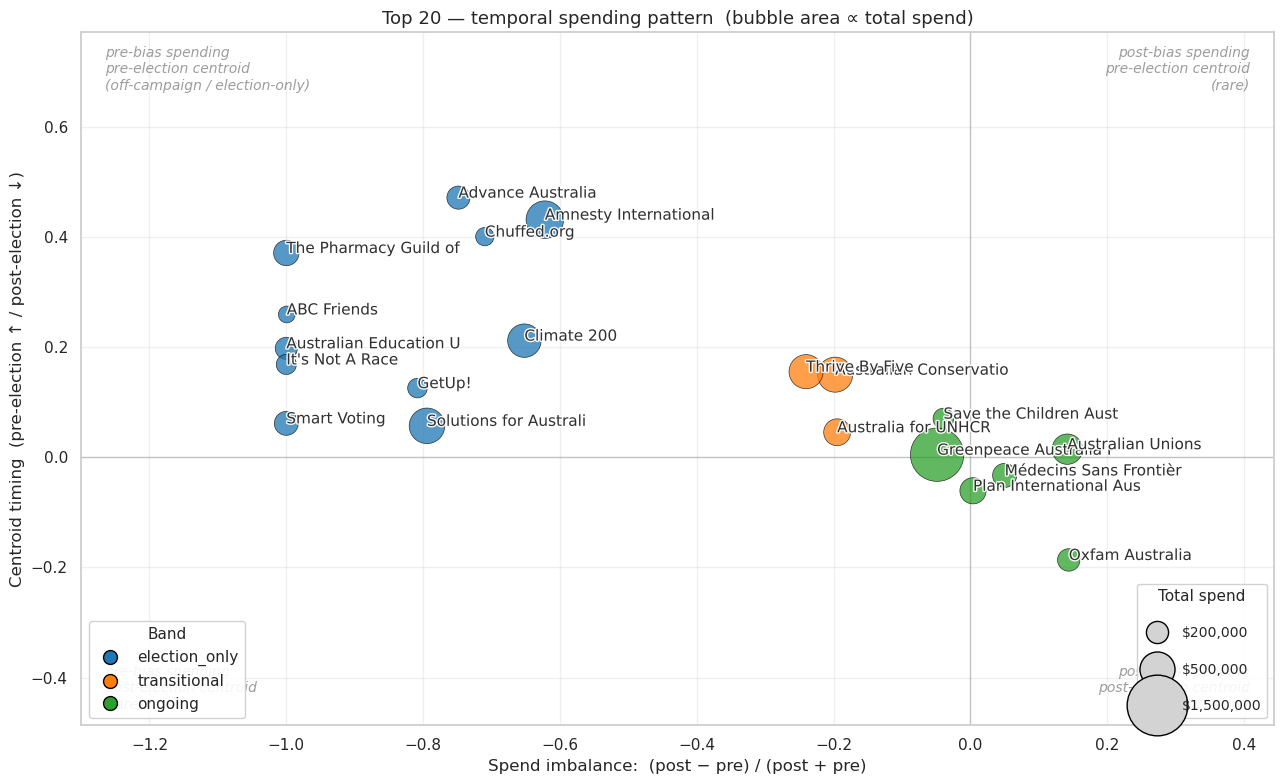

In [9]:
# temporal-pattern quadrant — spend imbalance (x) × centroid timing (y).

BAND_COLORS = {
    'election_only':   '#1f77b4',   # blue
    'transitional':    '#ff7f0e',   # orange
    'ongoing':         '#2ca02c',   # green
}

# axes — signed, normalised to ±1.
total = (top20['pre_spend'] + top20['post_spend']).replace(0, 1)
top20['x_imbalance'] = (top20['post_spend'] - top20['pre_spend']) / total
top20['y_centroid']  = (-top20['centroid_weeks'] / 26).clip(-1, 1)   # +ve = pre, −ve = post


def plot_quadrant(data, size_col, size_divisor, ref_sizes, size_legend_title,
                  size_label_fmt, chart_title):
    fig, ax = plt.subplots(figsize=(13, 8))

    ax.axhline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)
    ax.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)

    sizes = data[size_col] / size_divisor
    colors = data['band'].astype(str).map(BAND_COLORS)
    ax.scatter(
        data['x_imbalance'], data['y_centroid'],
        s=sizes, c=colors, alpha=0.75,
        edgecolors='black', linewidths=0.5, zorder=3,
    )

    # labels — adjustText pushes them off the bubbles with leader lines.
    texts = [
        ax.text(row['x_imbalance'], row['y_centroid'], row['bylines'][:22],
                fontsize=11, alpha=0.95, zorder=5)
        for _, row in data.iterrows()
    ]

    try:
        from adjustText import adjust_text
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.6),
            expand_points=(2.0, 2.0),
            expand_text=(1.4, 1.6),
            force_points=(0.6, 0.8),
            force_text=(0.7, 0.9),
            lim=500,
            only_move={'points': 'xy', 'text': 'xy', 'objects': 'xy'},
        )
    except ImportError:
        from matplotlib import patheffects
        for t in texts:
            t.set_path_effects([patheffects.withStroke(linewidth=2.0, foreground='white')])

    # quadrant labels positioned in axes coordinates so they sit in the corners
    # regardless of the data range.
    ax.text(0.02, 0.98, 'pre-bias spending\npre-election centroid\n(off-campaign / election-only)',
            transform=ax.transAxes, ha='left',  va='top',
            fontsize=10, alpha=0.45, fontstyle='italic')
    ax.text(0.98, 0.98, 'post-bias spending\npre-election centroid\n(rare)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, alpha=0.45, fontstyle='italic')
    ax.text(0.02, 0.02, 'pre-bias spending\npost-election centroid\n(rare)',
            transform=ax.transAxes, ha='left',  va='bottom',
            fontsize=10, alpha=0.45, fontstyle='italic')
    ax.text(0.98, 0.02, 'post-bias spending\npost-election centroid\n(post-only)',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, alpha=0.45, fontstyle='italic')

    from matplotlib.lines import Line2D
    band_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
        for b, c in BAND_COLORS.items()
    ]
    # Line2D markersize is diameter in points → 2 * sqrt(area / pi).
    size_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor='lightgray', markeredgecolor='black',
               markersize=2 * np.sqrt((s / size_divisor) / np.pi),
               label=size_label_fmt(s))
        for s in ref_sizes
    ]
    band_legend = ax.legend(handles=band_handles, loc='lower left', fontsize=11,
                            framealpha=0.9, title='Band', title_fontsize=11)
    ax.add_artist(band_legend)
    ax.legend(handles=size_handles, loc='lower right', fontsize=10, framealpha=0.9,
              title=size_legend_title, title_fontsize=11, labelspacing=1.6)

    # Auto-fit axes to data with 10% padding on each side. Ensure 0 stays in
    # range so the quadrant cross-hair (axhline / axvline) remains visible.
    x_min, x_max = data['x_imbalance'].min(), data['x_imbalance'].max()
    y_min, y_max = data['y_centroid'].min(), data['y_centroid'].max()
    x_pad = max((x_max - x_min) * 0.10, 0.3)
    y_pad = max((y_max - y_min) * 0.10, 0.3)
    ax.set_xlim(min(x_min - x_pad, -0.05), max(x_max + x_pad, 0.05))
    ax.set_ylim(min(y_min - y_pad, -0.05), max(y_max + y_pad, 0.05))

    ax.set_xlabel('Spend imbalance:  (post − pre) / (post + pre)', fontsize=12)
    ax.set_ylabel('Centroid timing  (pre-election ↑ / post-election ↓)', fontsize=12)
    ax.set_title(chart_title, fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()


plot_quadrant(
    top20,
    size_col='total_spend',
    size_divisor=1000,
    ref_sizes=[200_000, 500_000, 1_500_000],
    size_legend_title='Total spend',
    size_label_fmt=lambda s: f'${s:,.0f}',
    chart_title='Top 20 — temporal spending pattern  (bubble area ∝ total spend)',
)

same quadrant, bubble area is impressions instead of spend. comparison table at the end for spend rank vs impression rank.

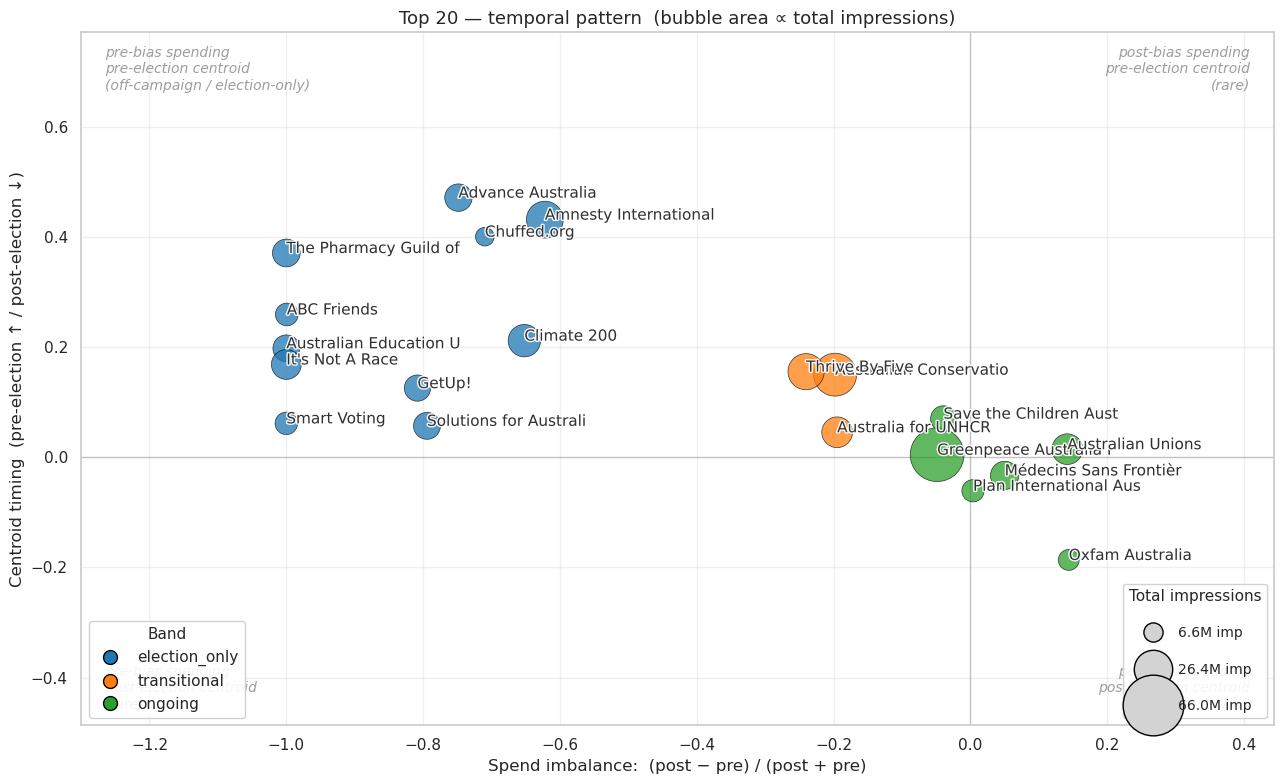

,bylines,spend_rank,imp_rank,rank_shift,cpm
2,Solutions for Australia,3,12,-9,39.630781
14,Plan International Australia,9,18,-9,31.598393
7,Smart Voting,12,17,-5,25.750879
19,Oxfam Australia,14,19,-5,26.418023
15,Chuffed.org,19,20,-1,21.977534
1,Amnesty International Australia,2,3,-1,23.532153
6,The Pharmacy Guild of Australia,10,10,0,19.130007
12,Australian Unions,7,7,0,22.308006
0,Greenpeace Australia Pacific,1,1,0,22.418309
3,Climate 200,6,5,1,24.231132


In [10]:
# aggregate total impressions per top-20 byline from v3.
imp_pdf = (v3
    .filter(col('bylines').isin(top20_bylines) & col('impressions_mid').isNotNull())
    .groupBy('bylines')
    .agg(spark_sum('impressions_mid').alias('total_impressions'))
    .toPandas())

top20_imp = top20.merge(imp_pdf, on='bylines', how='left')
top20_imp['total_impressions'] = top20_imp['total_impressions'].fillna(0)

# scale so the biggest bubble is similar to the spend chart.
imp_divisor = top20_imp['total_impressions'].max() / 1500
imp_max = top20_imp['total_impressions'].max()

plot_quadrant(
    top20_imp,
    size_col='total_impressions',
    size_divisor=imp_divisor,
    ref_sizes=[imp_max * 0.1, imp_max * 0.4, imp_max],
    size_legend_title='Total impressions',
    size_label_fmt=lambda s: f'{s/1e6:,.1f}M imp',
    chart_title='Top 20 — temporal pattern  (bubble area ∝ total impressions)',
)

# spend rank vs impression rank.
cmp = top20_imp[['bylines', 'total_spend', 'total_impressions']].copy()
cmp['spend_rank'] = cmp['total_spend'].rank(ascending=False).astype(int)
cmp['imp_rank']   = cmp['total_impressions'].rank(ascending=False).astype(int)
cmp['cpm']        = cmp['total_spend'] / (cmp['total_impressions'] / 1000).replace(0, pd.NA)
cmp['rank_shift'] = cmp['spend_rank'] - cmp['imp_rank']
cmp.sort_values('rank_shift')[['bylines', 'spend_rank', 'imp_rank', 'rank_shift', 'cpm']]

roll up to bands. count, total spend, mean persistence and EC per band.

In [11]:
band_summary = top20.groupby('band', observed=True).agg(
    n_advertisers=('bylines', 'count'),
    pre_spend=('pre_spend', 'sum'),
    post_spend=('post_spend', 'sum'),
    total_spend=('total_spend', 'sum'),
    mean_persistence=('persistence', 'mean'),
    mean_ec=('ec_index', 'mean'),
).reset_index()

band_summary['total_share'] = band_summary['total_spend'] / band_summary['total_spend'].sum()

band_summary

,band,n_advertisers,pre_spend,post_spend,total_spend,mean_persistence,mean_ec,total_share
0,election_only,11,3471024.5,385375.5,3856400.0,0.088525,0.668587,0.449894
1,transitional,3,979852.0,635773.0,1615625.0,0.690764,0.592905,0.188481
2,ongoing,6,1529484.5,1570291.0,3099775.5,1.152543,0.561230,0.361625


the advocacy ecosystem splits into four patterns, with election_only the biggest by count and greenpeace dominating the ongoing band. shell only shows up as off_campaign once you combine persistence with centroid.

In [12]:
BAND_EXPORT_PATH = '../data/top20_bands.csv'

export_df = (top20[['bylines', 'band', 'group', 'pre_spend', 'post_spend',
                     'total_spend', 'persistence', 'centroid_weeks', 'ec_index']]
             .sort_values(['band', 'total_spend'], ascending=[True, False])
             .reset_index(drop=True))
export_df['band'] = export_df['band'].astype(str)

export_df.to_csv(BAND_EXPORT_PATH, index=False)
print(f'Wrote {BAND_EXPORT_PATH}')
display(export_df)

Wrote ../data/top20_bands.csv


,bylines,band,group,pre_spend,post_spend,total_spend,persistence,centroid_weeks,ec_index
0,Amnesty International Australia,election_only,humanitarian_rights,591343.5,137758.0,729101.5,0.229716,-11.205481,0.412767
1,Solutions for Australia,election_only,climate,588191.0,67405.0,655596.0,0.125246,-1.475849,0.852048
2,Climate 200,election_only,political_advocacy,479677.0,101032.0,580709.0,0.208811,-5.495480,0.517789
3,The Pharmacy Guild of Australia,election_only,cost_of_living,335291.5,0.0,335291.5,0.000000,-9.633387,0.629485
4,Smart Voting,election_only,political_advocacy,297473.5,0.0,297473.5,0.000000,-1.592509,0.938750
5,Advance Australia,election_only,political_advocacy,242332.0,34869.5,277201.5,0.118869,-12.244064,0.365140
6,Australian Education Union,election_only,climate,253022.5,0.0,253022.5,0.000000,-5.134448,0.802521
7,It's Not A Race,election_only,political_advocacy,209553.0,0.0,209553.0,0.000000,-4.371965,0.831847
8,GetUp!,election_only,political_advocacy,179247.5,18999.5,198247.0,0.106415,-3.256904,0.768834
9,Chuffed.org,election_only,humanitarian_rights,148874.5,25262.0,174136.5,0.184374,-10.402506,0.494781


export top 20 bylines + band as csv for nb 06 to consume.

for each of the three main bands (election_only, transitional, ongoing), show every advertiser and their top 5 keywords from ad body + title text. regex tokenise, lowercase, drop stopwords.

In [13]:
from pyspark.sql.functions import (
    row_number, explode, lower, regexp_replace, split, length,
    concat_ws, array_join, collect_list,
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StopWordsRemover

# english stopwords plus a few domain words that don't differentiate australian
# political advocacy bylines (everyone says 'australia', 'sign', etc).
STOP = set(StopWordsRemover.loadDefaultStopWords('english')) | {
    'australia', 'australian', 'australians', 'sign', 'petition', 'please',
    'today', 'help', 'support', 'make', 'get', 'one', 'us', 'go',
    'http', 'https', 'www', 'com', 'au',
}

top_keywords_by_band = {}
for band_name in ['election_only', 'transitional', 'ongoing']:
    band_bylines = top20.loc[top20['band'] == band_name, 'bylines'].tolist()
    if not band_bylines:
        top_keywords_by_band[band_name] = pd.DataFrame()
        continue

    # combine body + title arrays into one text blob per ad, tokenise.
    tokens = (v3
        .filter(col('bylines').isin(band_bylines))
        .withColumn('text', concat_ws(' ',
            array_join('creative_bodies', ' '),
            array_join('creative_link_titles', ' ')))
        .withColumn('text', regexp_replace(lower('text'), r'[^a-z\s]', ' '))
        .withColumn('token', explode(split(col('text'), r'\s+')))
        .filter(length('token') > 2)
        .filter(~col('token').isin(list(STOP))))

    counts = tokens.groupBy('bylines', 'token').count()
    w = Window.partitionBy('bylines').orderBy(desc('count'), 'token')
    top5 = (counts
        .withColumn('rn', row_number().over(w))
        .filter(col('rn') <= 5)
        .orderBy('bylines', 'rn')
        .groupBy('bylines')
        .agg(collect_list('token').alias('top_keywords'))
        .toPandas())

    # preserve band ordering by total spend.
    order = (top20.loc[top20['band'] == band_name]
                  .sort_values('total_spend', ascending=False)['bylines']
                  .tolist())
    top5['_order'] = top5['bylines'].map({b: i for i, b in enumerate(order)})
    top5 = top5.sort_values('_order').drop(columns='_order').reset_index(drop=True)
    top5['top_keywords'] = top5['top_keywords'].apply(lambda xs: ', '.join(xs))
    top_keywords_by_band[band_name] = top5

for band_name, df in top_keywords_by_band.items():
    print(f'\n=== {band_name} ({len(df)} advertisers) ===')
    display(df)


=== election_only (11 advertisers) ===


,bylines,top_keywords
0,Amnesty International Australia,"quiz, people, take, rights, minute"
1,Solutions for Australia,"energy, power, government, federal, jobs"
2,Climate 200,"climate, vote, independent, party, independents"
3,The Pharmacy Guild of Australia,"medicines, cost, prescription, visit, choose"
4,Smart Voting,"last, put, liberals, afford, source"
5,Advance Australia,"vaccine, freedom, fair, show, choice"
6,Australian Education Union,"morrison, government, vote, schools, tafe"
7,It's Not A Race,"auspol, climate, climateaction, change, right"
8,GetUp!,"vote, election, government, climate, morrison"
9,Chuffed.org,"people, aboriginal, chip, first, birth"



=== transitional (3 advertisers) ===


,bylines,top_keywords
0,Australian Conservation Foundation,"protect, climb, climate, laws, nature"
1,Thrive By Five,"early, learning, educators, childcare, families"
2,Australia for UNHCR,"refugees, donate, winter, unhcr, families"



=== ongoing (6 advertisers) ===


,bylines,top_keywords
0,Greenpeace Australia Pacific,"woodside, gas, tell, climate, oceans"
1,Australian Unions,"union, free, join, joining, unions"
2,Plan International Australia,"girls, add, fgm, name, every"
3,Médecins Sans Frontières Australia,"medical, people, care, teams, need"
4,Oxfam Australia,"conflict, people, hunger, government, food"
5,Save the Children Australia,"children, child, end, many, governments"
